# Creamos una Nube de Palabras (WordCloud)

Vamos a comenzar el curso con una de las técnicas más simples (pero a su vez de las más utilizadas) de análisis de textos por computadora.

Una nube de palabras (también llamada nube de tags o WordClouds) es la representación gráfica de las palabras más usadas en un texto. Consiste en determinar el número de veces que se repiten las palabras haciendo que éstas aparezcan destacadas en la representación, generalmente con un tamaño mayor.

En Pyhton se pueden crear facilmente a través de la librería WordCloud, pero antes vamos a ver los pasos que involucra.

Cargamos un texto directamente en una variable

In [ ]:
texto = 'El procesamiento de lenguaje natural​ abreviado  es un campo de las ciencias de la computación, de la inteligencia artificial y de la lingüística que estudia las interacciones entre las computadoras y el lenguaje humano. Se ocupa de la formulación e investigación de mecanismos eficaces computacionalmente para la comunicación entre personas y máquinas por medio del lenguaje natural, es decir, de las lenguas del mundo. No trata de la comunicación por medio de lenguas naturales de una forma abstracta, sino de diseñar mecanismos para comunicarse que sean eficaces computacionalmente —que se puedan realizar por medio de programas que ejecuten o simulen la comunicación—. Los modelos aplicados se enfocan no solo a la comprensión del lenguaje de por sí, sino a procesar aspectos generales cognitivos humanos y a la organización de la memoria. El lenguaje natural sirve solo de medio para estudiar estos fenómenos. Hasta la década de 1980, la mayoría de los sistemas de PLN se basaban en un complejo conjunto de reglas diseñadas a mano. A partir de finales de 1980, sin embargo, hubo una revolución en PLN con la introducción de algoritmos de aprendizaje automático para el procesamiento del lenguaje. La historia del PLN empieza desde 1950, aunque se han encontrado trabajos anteriores. En 1950, Alan Turing publicó Computing machinery and intelligence, donde proponía lo que hoy se llama el test de turing como criterio de inteligencia. En 1954, el experimento de Georgetown involucró traducción automática de más de sesenta oraciones del ruso al inglés. Los autores sostuvieron que en tres o cinco años la traducción automática sería un problema resuelto. El avance real en traducción automática fue más lento, y en 1966 el reporte ALPAC demostró que la investigación había tenido un bajo desempeño. Más tarde, hasta finales de 1980, se llevaron a cabo investigaciones a menor escala en traducción automática, y se desarrollaron los primeros sistemas de traducción automática estadística. Esto se debió tanto al aumento constante del poder de cómputo resultante de la ley de Moore como a la disminución gradual del predominio de las teorías lingüísticas de Noam Chomsky (por ejemplo, la gramática transformacional), cuyos fundamentos teóricos desalentaron el tipo de lingüística de corpus, que se basa en el enfoque de aprendizaje de máquinas para el procesamiento del lenguaje. Se usaron entonces los primeros algoritmos de aprendizaje automático, como los árboles de decisión, sistemas producidos de sentencias si-entonces similares a las reglas escritas a mano. Se puede consultar un resumen de la historia de 50 años de publicaciones acerca del procesamiento automático después del proyecto NLP4NLP en una publicación doble en Frontiers in Research Metrics and Analytics'

Primero tenemos que separar las pablabras en tokens. En la Unidad 3 veremos más en detalle en este proceso, pero por ahora entendamos que es preciso indicarle a la computadora que la unidad mínima con la que estamos trabajando son las palabras (y no las letras o las oraciones, por ejemplo).

In [ ]:
type(texto)

str

In [ ]:
texto

'El procesamiento de lenguaje natural\u200b abreviado  es un campo de las ciencias de la computación, de la inteligencia artificial y de la lingüística que estudia las interacciones entre las computadoras y el lenguaje humano. Se ocupa de la formulación e investigación de mecanismos eficaces computacionalmente para la comunicación entre personas y máquinas por medio del lenguaje natural, es decir, de las lenguas del mundo. No trata de la comunicación por medio de lenguas naturales de una forma abstracta, sino de diseñar mecanismos para comunicarse que sean eficaces computacionalmente —que se puedan realizar por medio de programas que ejecuten o simulen la comunicación—. Los modelos aplicados se enfocan no solo a la comprensión del lenguaje de por sí, sino a procesar aspectos generales cognitivos humanos y a la organización de la memoria. El lenguaje natural sirve solo de medio para estudiar estos fenómenos. Hasta la década de 1980, la mayoría de los sistemas de PLN se basaban en un com

In [ ]:
from nltk import RegexpTokenizer
pattern1 = r'\w+'
tokenizer = RegexpTokenizer(pattern1) #instanciamos nuestro separador de palabras

tokens_texto = tokenizer.tokenize(texto)
print(tokens_texto)


['El', 'procesamiento', 'de', 'lenguaje', 'natural', 'abreviado', 'es', 'un', 'campo', 'de', 'las', 'ciencias', 'de', 'la', 'computación', 'de', 'la', 'inteligencia', 'artificial', 'y', 'de', 'la', 'lingüística', 'que', 'estudia', 'las', 'interacciones', 'entre', 'las', 'computadoras', 'y', 'el', 'lenguaje', 'humano', 'Se', 'ocupa', 'de', 'la', 'formulación', 'e', 'investigación', 'de', 'mecanismos', 'eficaces', 'computacionalmente', 'para', 'la', 'comunicación', 'entre', 'personas', 'y', 'máquinas', 'por', 'medio', 'del', 'lenguaje', 'natural', 'es', 'decir', 'de', 'las', 'lenguas', 'del', 'mundo', 'No', 'trata', 'de', 'la', 'comunicación', 'por', 'medio', 'de', 'lenguas', 'naturales', 'de', 'una', 'forma', 'abstracta', 'sino', 'de', 'diseñar', 'mecanismos', 'para', 'comunicarse', 'que', 'sean', 'eficaces', 'computacionalmente', 'que', 'se', 'puedan', 'realizar', 'por', 'medio', 'de', 'programas', 'que', 'ejecuten', 'o', 'simulen', 'la', 'comunicación', 'Los', 'modelos', 'aplicados', 

In [ ]:
tokens_texto[1]

'procesamiento'

In [ ]:
from nltk import FreqDist #Además podemos generar un diccionario de frecuencias

frecuencia = FreqDist(tokens_texto)
frecuencia

FreqDist({'de': 46, 'la': 19, 'del': 11, 'se': 9, 'a': 9, 'en': 9, 'que': 8, 'el': 8, 'lenguaje': 7, 'las': 6, ...})

In [ ]:
#Ordenamos el resultado haciendo pandas

import pandas as pd

df = pd.DataFrame([[key, frecuencia[key]] for key in frecuencia.keys()], columns=['Token', 'Frecuencia'])

print(df.sort_values(by='Frecuencia', ascending=False)) # Imprimo ordenando por frecuencia (invertido)



            Token  Frecuencia
2              de          46
11             la          19
38            del          11
65              a           9
52             se           9
..            ...         ...
100           con           1
101  introducción           1
105            La           1
107       empieza           1
227     Analytics           1

[228 rows x 2 columns]


Visualizamos en un gráfico

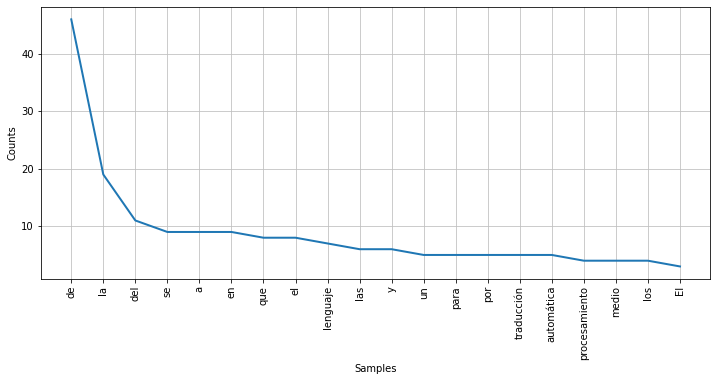

In [ ]:
from nltk import FreqDist #Además podemos generar un diccionario de frecuencias propio de nltk

fdist1 = FreqDist(tokens_texto)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))  # the size


fdist1.plot(20, cumulative=False)

Como vemos, las palabras más frecuentes en el texto son aquellas que tienen, en general, baja carga semántica y que mayormente querríamos eliminar. Este conjunto se denomina **STOPWORDS**

In [ ]:
import nltk
nltk.download('stopwords')
import nltk
nltk.download('punkt')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('spanish'))
stop_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


{'a',
 'al',
 'algo',
 'algunas',
 'algunos',
 'ante',
 'antes',
 'como',
 'con',
 'contra',
 'cual',
 'cuando',
 'de',
 'del',
 'desde',
 'donde',
 'durante',
 'e',
 'el',
 'ella',
 'ellas',
 'ellos',
 'en',
 'entre',
 'era',
 'erais',
 'eran',
 'eras',
 'eres',
 'es',
 'esa',
 'esas',
 'ese',
 'eso',
 'esos',
 'esta',
 'estaba',
 'estabais',
 'estaban',
 'estabas',
 'estad',
 'estada',
 'estadas',
 'estado',
 'estados',
 'estamos',
 'estando',
 'estar',
 'estaremos',
 'estará',
 'estarán',
 'estarás',
 'estaré',
 'estaréis',
 'estaría',
 'estaríais',
 'estaríamos',
 'estarían',
 'estarías',
 'estas',
 'este',
 'estemos',
 'esto',
 'estos',
 'estoy',
 'estuve',
 'estuviera',
 'estuvierais',
 'estuvieran',
 'estuvieras',
 'estuvieron',
 'estuviese',
 'estuvieseis',
 'estuviesen',
 'estuvieses',
 'estuvimos',
 'estuviste',
 'estuvisteis',
 'estuviéramos',
 'estuviésemos',
 'estuvo',
 'está',
 'estábamos',
 'estáis',
 'están',
 'estás',
 'esté',
 'estéis',
 'estén',
 'estés',
 'fue',
 'f

In [ ]:
#Modificar Stop Words de NLTK
remover = {'algunas', 'a', 'en'} #Escribir aquí las palabras que se quiere sacar de la lista de stopwords de nltk

stop_words_modificadas = set([word for word in stop_words if word not in remover])



In [ ]:
#Eliminación de stopwords

tokens_filtrados = []


for t in tokens_texto:
    t = t.lower()
    if t not in stop_words:
        tokens_filtrados.append(t)


frec_filtrada = FreqDist(tokens_filtrados)

In [ ]:
#Ordenamos el resultados filtrados haciendo pandas

import pandas as pd

df = pd.DataFrame([[key, frec_filtrada[key]] for key in frec_filtrada.keys()], columns=['Token', 'Frecuencia'])

print(df.sort_values(by='Frecuencia', ascending=False)) # Imprimo ordenando por frecuencia (invertido)

             Token  Frecuencia
1         lenguaje           7
97      automática           5
96      traducción           5
0    procesamiento           4
23           medio           4
..             ...         ...
69    introducción           1
74         empieza           1
76          aunque           1
77      encontrado           1
177      analytics           1

[178 rows x 2 columns]


In [ ]:
#print(tokens_filtrados)
set(tokens_filtrados)

plt.figure(figsize=(14, 3))  # the size

fdist2 = FreqDist(tokens_filtrados)
fdist2

fdist2.plot(50, cumulative=False)

NameError: ignored

Ahora podemos crear la nube de palabras con la librería WordCloud, que efectúa la tokenización y conteo de manera automática

In [ ]:
! pip install WordCloud

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


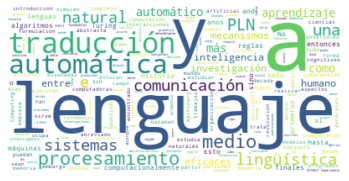

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud


#stop_words = []
stop_words = ['de','la','para','del','El','que','las','se','por','uno','en','lo','un', 'los'] #Probar cómo cambia el resultado cuando se descomenta esta línea



word_cloud = WordCloud(collocations = False, background_color = 'white', stopwords=stop_words).generate(texto)

plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

Una vez que hemos eliminado las stopwords, nuestra Nube de Palabras se vuelve más representativa del texto con el que estamos trabajando. Hasta este punto, hemos partido de un texto crudo al que aplicamos distintos métodos para obtener sus unidades mínimas (tokens, palabras, etc).

Pero para poder avanzar en el procesamiento necesitaríamos que nuestro programa, además de distinguir tokens semánticamente relevantes de aquellos irrelevantes, pueda identificar por ejemplo todas las formas en que aparece conjugado el verbo 'procesar' como una única aparición ese concepto y no como apariciones aisladas.

In [ ]:
import re
pattern = re.compile(r'proce.*')

proces = []
for token in tokens_texto:
    proces.extend(re.findall(pattern, token))

print(proces[0:2])

['procesamiento', 'procesar']


# Carga de Archivos de texto en Python

En la clase vamos a trabajar con Notebooks montados en Google Colab, que es una herramienta gratuita que permite correr el código en la nube. De esta manera el código funcionará igual para todos/as sin importar el equipo con el que cuenten.

Para cargar los datasets previamente hay que subirlos a Google Drive, y luego correr la celda que se encuentra a continuación. Se creará un link, que hay que seguir para autentificar el acceso y luego copiar en el cuadro de Input el token que se crea.

Con esto ya se puede trabajar con el Drive como si fuera un directorio local. Para buscar los paths de los archivos ir al menú izquierdo > Files > gdrive > MyDrive, y buscar la carpeta donde de guardaron los datasets. Clickear en los tres botones de la derecha, y seleccionar Copy Path.

*También está la posiblidad de descargar los archivos y correrlos en Anaconda, para lo cual hay que hacer click en File > Download > Download .ipnyb*

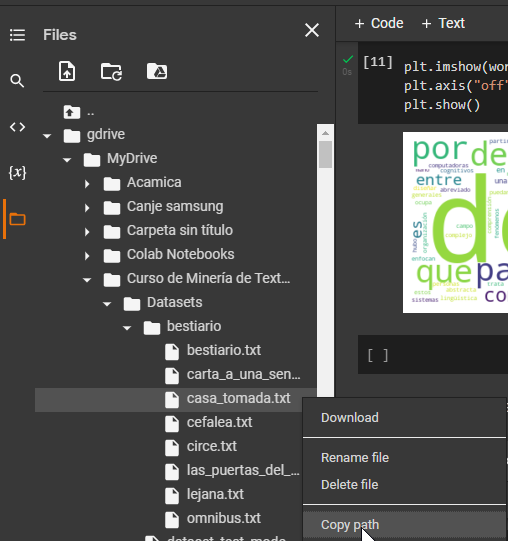

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
##Correr para subir el archivo desde un fichero local

from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['descarga (4).csv']))
print(df)


Saving descarga (4).csv to descarga (4) (1).csv
     Unnamed: 0                                            Message Sentimiento
0             0         Exigimos cadena perpetua para Arturo Vidal      Neutro
1             1  Que es cuma este wn...\nCero decencia\nBorrach...      Neutro
2             2                 Tomo como reyyy artuloooooo jjajaj      Neutro
3             3                              El rey de los flyates      Neutro
4             4                                   mi reysito bello      Neutro
..          ...                                                ...         ...
995         995                          @pumba @DIRECTVGO vale...      Neutro
996         996      William Alexander Vela Becerra te mandé inbox      Neutro
997         997                               Javier Sánchez Lagos      Neutro
998         998  1 PANTALLA HBO GO POR TAN SOLO 15.000 Pesos Co...      Neutro
999         999                                        vale gracia      Neutro

[10

Buscamos el la carpeta de Datasets en Drive, y abrimos el texto de la novela Cien Años de Soledad




**Algunos modos de manipulación de textos:**


f = open('hola.txt', 'w') # El objeto del archivo en modo escritura es asignado a la variable f (o a la que quiera) print(f)


'w': abre un archivo en modo escritura. Si el archivo no existe, lo creará. Y si ya existe, reemplazará el viejo archivo con el nuevo que estamos creando.

'r': abre una rchivo en modo lectura. No podemos escribir en él pero sí leerlo. Si el archivo no existe,  devolverá un error.

**Métodos para manipular textos:**

.read(): lee un archivo de texto.

.write(): añade un determinado texto.

El texto a agregar debe ser escrito entre comillas dentro de los paréntesis.

.readline(): devuelve la primera línea del texto hasta que haya un salto.

.readlines(): devuelve una lista donde cada elemento es una línea del texto.

.close(): cierra el archivo de texto.

In [ ]:
f = open("/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/gabriel_garcia_marquez_cien_annos_soledad.txt", "r")
texto_read = f.read()
f.close()
#print(texto_read)
#print(type(texto_read))
print(texto_read[1000:2000])


el nombre de Melquíades, hizo una 
truculenta demostración pública de lo que él mismo llamaba la octava maravilla de los sabios 
alquimistas de Macedonia. Fue de casa en casa arrastrando dos lingotes metálicos, y todo el 
mundo se espantó al ver que los calderos, las pailas, las tenazas y los anafes se caían de su sitio, 
y las maderas crujían por la desesperación de los clavos y los tornillos tratando de desenclavarse, 
y aun los objetos perdidos desde hacía mucho tiempo aparecían por donde más se les había 
buscado, y se arrastraban en desbandada turbulenta detrás de los fierros mágicos de Melquíades. 
«Las cosas, tienen vida propia -pregonaba el gitano con áspero acento-, todo es cuestión de 
despertarles el ánima.» José Arcadio Buendía, cuya desaforada imaginación iba siempre más lejos 
que el ingenio de la naturaleza, y aun más allá del milagro y la magia, pensó que era posible 
servirse de aquella invención inútil para desentrañar el oro de la tierra. Melquíades, que era un 
homb

In [ ]:
f = open(r'/content/gdrive/MyDrive/Curso de Minería de Textos/Datasets/gabriel_garcia_marquez_cien_annos_soledad.txt', 'r', encoding='utf-8')
lineas_cien_annos = f.readlines() #[f.strip('\n').strip() for f in f.readlines() if f != '\n'] para quitar los \n
f.close()

for line in lineas_cien_annos[25:35]:##Cambiar acá para elegir la cantidad de líneas a imprimir
    print(line) #line[1:22] para elegir la cantidad de caracteres por línea

Muchos años después, frente al pelotón de fusilamiento, el coronel Aureliano Buendía había de 

recordar aquella tarde remota en que su padre lo llevó a conocer el hielo. Macondo era entonces 

una aldea de veinte casas de barro y cañabrava construidas a la orilla de un río de aguas diáfanas 

que se precipitaban por un lecho de piedras pulidas, blancas y enormes como huevos 

prehistóricos. El mundo era tan reciente, que muchas cosas carecían de nombre, y para 

mencionarlas había que señalarías con el dedo. Todos los años, por el mes de marzo, una familia 

de gitanos desarrapados plantaba su carpa cerca de la aldea, y con un grande alboroto de pitos y 

timbales daban a conocer los nuevos inventos. Primero llevaron el imán. Un gitano corpulento, de 

barba montaraz y manos de gorrión, que se presentó con el nombre de Melquíades, hizo una 

truculenta demostración pública de lo que él mismo llamaba la octava maravilla de los sabios 



In [ ]:
for line in lineas_cien_annos[25:35]:
    print(line.split(' '))

['Muchos', 'años', 'después,', 'frente', 'al', 'pelotón', 'de', 'fusilamiento,', 'el', 'coronel', 'Aureliano', 'Buendía', 'había', 'de', '\n']
['recordar', 'aquella', 'tarde', 'remota', 'en', 'que', 'su', 'padre', 'lo', 'llevó', 'a', 'conocer', 'el', 'hielo.', 'Macondo', 'era', 'entonces', '\n']
['una', 'aldea', 'de', 'veinte', 'casas', 'de', 'barro', 'y', 'cañabrava', 'construidas', 'a', 'la', 'orilla', 'de', 'un', 'río', 'de', 'aguas', 'diáfanas', '\n']
['que', 'se', 'precipitaban', 'por', 'un', 'lecho', 'de', 'piedras', 'pulidas,', 'blancas', 'y', 'enormes', 'como', 'huevos', '\n']
['prehistóricos.', 'El', 'mundo', 'era', 'tan', 'reciente,', 'que', 'muchas', 'cosas', 'carecían', 'de', 'nombre,', 'y', 'para', '\n']
['mencionarlas', 'había', 'que', 'señalarías', 'con', 'el', 'dedo.', 'Todos', 'los', 'años,', 'por', 'el', 'mes', 'de', 'marzo,', 'una', 'familia', '\n']
['de', 'gitanos', 'desarrapados', 'plantaba', 'su', 'carpa', 'cerca', 'de', 'la', 'aldea,', 'y', 'con', 'un', 'grande',

In [ ]:
print("El texto tiene " + str(len(lineas_cien_annos)) + " parráfos.")

for line in lineas_cien_annos[25:55]:
    parrafo_tokenizado = line.split(' ')
    cuantas_la = parrafo_tokenizado.count('Buendía')
    if cuantas_la == 1:
        print("En el párrafo " + str(lineas_cien_annos.index(line)) + " la palabra 'Buendía' está " + str(cuantas_la) + " vez.")
    elif cuantas_la != 0:
        print("En el párrafo " + str(lineas_cien_annos.index(line)) + " la palabra 'Buendía' está " + str(cuantas_la) + " veces.")

El texto tiene 11929 parráfos.
En el párrafo 25 la palabra 'Buendía' está 1 vez.
En el párrafo 44 la palabra 'Buendía' está 1 vez.
En el párrafo 53 la palabra 'Buendía' está 1 vez.


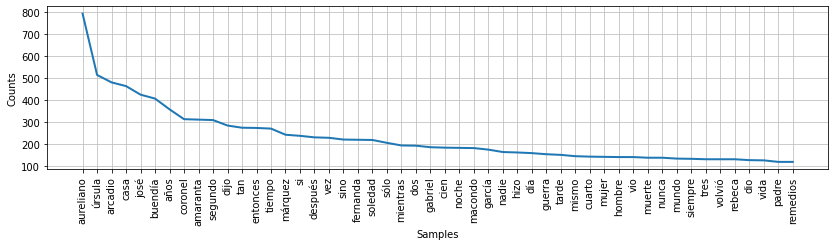

In [ ]:
tokens_reg = tokenizer.tokenize(texto_read)

from nltk.corpus import stopwords

stop_words = set(stopwords.words('spanish'))
stop_words

#Eliminación de stopwords

tokens_filtrados = []

for t in tokens_reg:
    t = t.lower()
    if t not in stop_words:
        tokens_filtrados.append(t)

#print(tokens_filtrados)
plt.figure(figsize=(14, 3))  # the size

fdist2 = FreqDist(tokens_filtrados)
fdist2

fdist2.plot(50, cumulative=False)